#### XOR 데이터 준비

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

def plot_points(X, Y, title="data"):
  Xn, Yn = X.detach().cpu(), Y.detach().cpu()
  plt.scatter(Xn[Yn[:,0]==0, 0], Xn[Yn[:,0]==0, 1], s=20, label="0")
  plt.scatter(Xn[Yn[:,0]==1, 0], Xn[Yn[:,0]==1, 1], s=20, label="1")
  plt.legend()
  plt.title(title)
  plt.show()

@torch.no_grad()
def plot_decision_boundary(predict_proba_fn, X, Y, title="decision boundary", xlim=(-0.5, 1.5), ylim=(-0.5, 1.5), steps=200):
  xs = torch.linspace(xlim[0], xlim[1], steps)
  ys = torch.linspace(ylim[0], ylim[1], steps)
  xx, yy = torch.meshgrid(xs, ys, indexing="ij")
  grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)
  probs = predict_proba_fn(grid).reshape(steps, steps)

  plt.contourf(xx.cpu(), yy.cpu(), probs.cpu(), levels=50, alpha=0.7)
  plt.contour(xx.cpu(), yy.cpu(), probs.cpu(), levels=[0.5], colors="black", linestyles="--")
  plot_points(X, Y, title=title)


## XOR 문제 직접 계산해 해결하기

라이브러리를 사용하지 않고 XOR 문제 해결하기

**Step 1. XOR 데이터 생성 (노이즈 추가)**

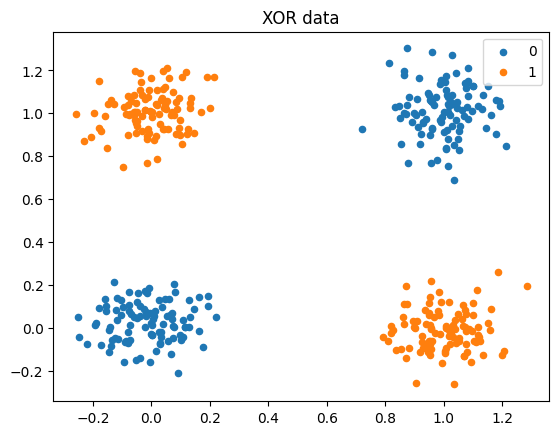

In [ ]:
torch.manual_seed(42)
base_X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
base_Y = torch.tensor([[0.],[1.],[1.],[0.]])

# 샘플 수 늘리기 + 노이즈
n_per = 100
X = base_X.repeat_interleave(n_per, dim=0) + 0.10*torch.randn(4*n_per, 2)
Y = base_Y.repeat_interleave(n_per, dim=0)

plot_points(X, Y, title="XOR data")


**Step 2. MLP 정의**

In [ ]:
torch.manual_seed(3)
hidden = 8

W1 = 0.5 * torch.randn(2, hidden)
b1 = torch.zeros(hidden)
W2 = 0.5 * torch.randn(hidden, 1)
b2 = torch.zeros(1)

def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

def bce_from_proba(p, y, eps=1e-7):
  return -(y * torch.log(p + eps) + (1 - y) * torch.log(1 - p + eps)).mean()

def forward_manual(X, Y, W1, b1, W2, b2):
  z1 = X @ W1 + b1
  a1 = sigmoid(z1)
  z2 = a1 @ W2 + b2
  p = sigmoid(z2)
  loss = bce_from_proba(p, Y)
  cache = {"X": X, "Y": Y, "z1": z1, "a1": a1, "z2": z2, "p": p}
  return loss, cache

@torch.no_grad()
def predict_proba(X, W1, b1, W2, b2):
  z1 = X @ W1 + b1
  a1 = sigmoid(z1)
  z2 = a1 @ W2 + b2 # @가 붙으면 안에서 로컬 gradient를 계산하지 않고 넘어감
  return sigmoid(z2)

loss, cache = forward_manual(X, Y, W1, b1, W2, b2)


**Step 3. 수동 역전파 함수 정의**

In [ ]:
def backward_manual(W2, cache):
  X, Y = cache["X"], cache["Y"]
  a1, p = cache["a1"], cache["p"]
  N = X.size(0)

  # 출력층
  dz2 = (p - Y) / N           # sigmoid + BCE → p - y 가 나옴
  dW2 = a1.t() @ dz2          # a1^T · dz2
  db2 = dz2.sum(0)            # batch 합

  # 은닉층
  da1 = dz2 @ W2.t()          # 이전층으로 gradient 전달
  dz1 = da1 * a1 * (1 - a1)   # sigmoid 미분
  dW1 = X.t() @ dz1           # X^T · dz1
  db1 = dz1.sum(0)            # batch 합

  return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2} # 우리가 궁금한 값들만 저장

**Step 4. 학습**

In [ ]:
torch.manual_seed(42)
hidden = 8

W1 = 0.5 * torch.randn(2, hidden)
b1 = torch.zeros(hidden)
W2 = 0.5 * torch.randn(hidden, 1)
b2 = torch.zeros(1)

lr = 0.8
epochs = 5000
losses, accs = [], []

for epoch in range(epochs):
  loss, cache = forward_manual(X, Y, W1, b1, W2, b2)
  grads = backward_manual(W2, cache)

  W1 -= lr * grads["dW1"]
  b1 -= lr * grads["db1"]
  W2 -= lr * grads["dW2"]
  b2 -= lr * grads["db2"]

  p = cache["p"]
  acc = ((p > 0.5).float() == Y).float().mean()

  losses.append(loss.item())
  accs.append(acc.item())

  if (epoch + 1) % 500 == 0:
    print(f"Epoch {epoch+1:4d} | loss {loss.item():.4f} | acc {acc.item():.4f}")


Epoch  500 | loss 0.1032 | acc 1.0000
Epoch 1000 | loss 0.0187 | acc 1.0000
Epoch 1500 | loss 0.0093 | acc 1.0000
Epoch 2000 | loss 0.0060 | acc 1.0000
Epoch 2500 | loss 0.0044 | acc 1.0000
Epoch 3000 | loss 0.0034 | acc 1.0000
Epoch 3500 | loss 0.0028 | acc 1.0000
Epoch 4000 | loss 0.0024 | acc 1.0000
Epoch 4500 | loss 0.0020 | acc 1.0000
Epoch 5000 | loss 0.0018 | acc 1.0000


**Step 5. Loss/Acc 그래프 & 결정경계 확인**

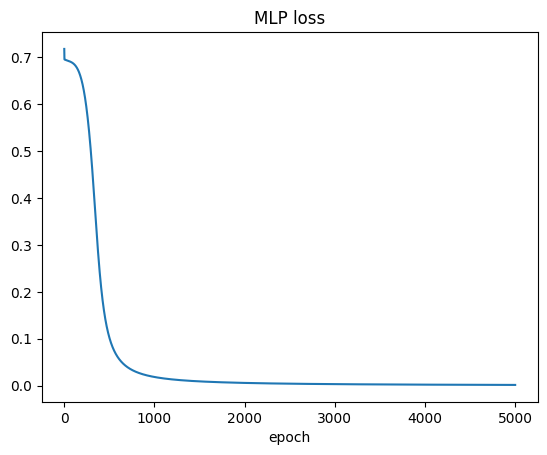

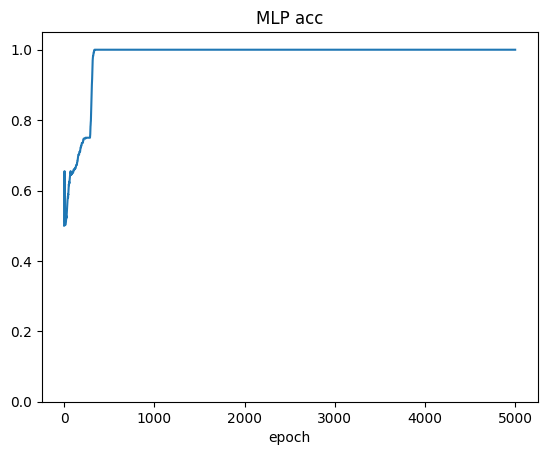

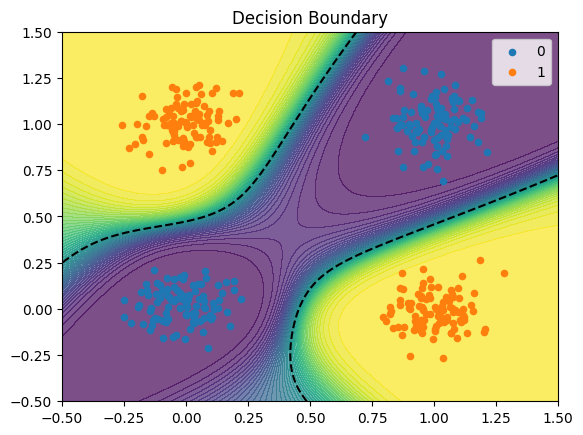

In [ ]:
plt.plot(losses)
plt.title("MLP loss")
plt.xlabel("epoch")
plt.show()

plt.plot(accs)
plt.title("MLP acc")
plt.xlabel("epoch")
plt.ylim(0, 1.05)
plt.show()

plot_decision_boundary(
    lambda G: predict_proba(G, W1, b1, W2, b2),
    X, Y,
    title="Decision Boundary"
)

## 자동미분 vs 수치미분

자동미분과 수치미분 비교하기

**Step 1. 수치미분 함수 정의**

In [8]:
import time
import torch

torch.manual_seed(42)

def numerical_grad_vec(f, theta, h=1e-6):
  grad = torch.zeros_like(theta)
  for i in range(theta.numel()):
    t_plus = theta.clone()
    t_minus = theta.clone()
    t_plus[i] += h
    t_minus[i] -= h
    grad[i] = (f(t_plus) - f(t_minus)) / (2 * h)
  return grad

**Step 2. 자동미분과 수치미분 결과 비교하기**

max_grad_diff=8.87e-09


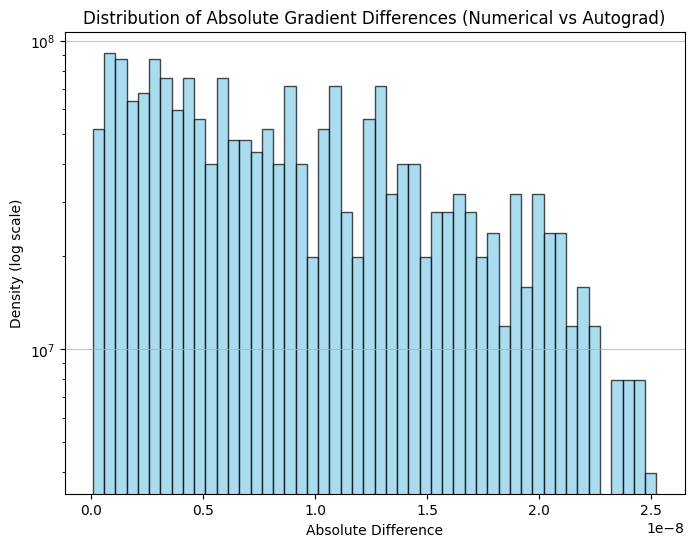

In [9]:
d = 500
theta = torch.randn(d, dtype=torch.float64)

start = time.time()
grad_num = numerical_grad_vec(lambda t: (t**2).sum(), theta)
t_num = time.time() - start

theta_ag = theta.clone().requires_grad_(True)
start = time.time()
loss = (theta_ag**2).sum()
loss.backward()
grad_auto = theta_ag.grad
t_auto = time.time() - start

mean_diff = (grad_num - grad_auto).abs().mean().item()

print(f"max_grad_diff={mean_diff:.2e}")

diffs = (grad_num - grad_auto).abs().flatten().numpy()

plt.figure(figsize=(8, 6))
plt.hist(diffs, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Distribution of Absolute Gradient Differences (Numerical vs Autograd)')
plt.xlabel('Absolute Difference')
plt.ylabel('Density (log scale)')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Step 3. 자동미분과 수치미분 시간 비교하기**

In [11]:
for d in [10, 100, 1000, 10000, 100000]:
  theta = torch.randn(d)

  start = time.time()
  _ = numerical_grad_vec(lambda t: (t**2).sum(), theta)
  t_num = time.time() - start

  theta_ag = theta.clone().requires_grad_(True)
  start = time.time()
  loss = (theta_ag**2).sum()
  loss.backward()
  t_auto = time.time() - start

  print(f"dim={d:4d} | numerical={t_num:.5f}s | autograd={t_auto:.5f}s")

dim=  10 | numerical=0.00221s | autograd=0.00038s
dim= 100 | numerical=0.00757s | autograd=0.00026s
dim=1000 | numerical=0.07657s | autograd=0.00023s
dim=10000 | numerical=0.83028s | autograd=0.00025s
dim=100000 | numerical=23.10826s | autograd=0.00045s


dimension이 10일때는 별 차이가 없지만, 커질 수록 차이가 심해짐

## 기울기 소실 실습

활성함수 선택에 따른 기울기 소실 실습하기

**Step 1. 자동미분과 수치미분 결과 비교하기**

In [12]:
class DeepMLP(nn.Module):
  def __init__(self, input_dim=64, hidden_dim=128, num_hidden=12, output_dim=2, activation="sigmoid"):
    super().__init__()

    layers = []
    in_dim = input_dim

    for i in range(num_hidden):
      layers.append((f"linear_{i+1}", nn.Linear(in_dim, hidden_dim)))
      if activation == "sigmoid":
        layers.append((f"act_{i+1}", nn.Sigmoid()))
      elif activation == "relu":
        layers.append((f"act_{i+1}", nn.ReLU()))
      else:
        raise ValueError("activation must be 'sigmoid' or 'relu'")
      in_dim = hidden_dim

    layers.append(("output", nn.Linear(hidden_dim, output_dim)))
    self.net = nn.Sequential(OrderedDict(layers))
    self.activation = activation

    self._initialize_weights()

  def _initialize_weights(self):
    # 활성함수 특성에 맞춰 초기화
    for m in self.modules():
      if isinstance(m, nn.Linear):
        if self.activation == "sigmoid":
          nn.init.xavier_normal_(m.weight)
        elif self.activation == "relu":
          nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)

  def forward(self, x):
    return self.net(x)

**Step 2. Gradient norm 측정 & 1회 역전파 데모 함수**

In [14]:
import torch.nn.functional as F
from collections import OrderedDict

def get_layer_grad_norms(model):
  grad_norms, layer_names = [], []
  for name, module in model.named_modules():
    if isinstance(module, nn.Linear):
      if module.weight.grad is not None:
        grad_norm = module.weight.grad.norm().item()
      else:
        grad_norm = 0.0
      grad_norms.append(grad_norm)
      layer_names.append(name)
  return layer_names, grad_norms

def run_single_backward_demo():
  x = torch.randn(32, 64).to(device)
  y = torch.randint(0, 2, (32,)).to(device)
  criterion = nn.CrossEntropyLoss()
  model_sig = DeepMLP(activation="sigmoid").to(device)
  loss = criterion(model_sig(x), y)
  loss.backward()
  names, grads_sig = get_layer_grad_norms(model_sig)
  model_relu = DeepMLP(activation="relu").to(device)
  loss = criterion(model_relu(x), y)
  loss.backward()
  _, grads_relu = get_layer_grad_norms(model_relu)
  return names, grads_sig, grads_relu

names, grads_sig, grads_relu = run_single_backward_demo()

print("[Sigmoid MLP] layer별 gradient norm")
for n, g in zip(names, grads_sig):
  print(f"{n}: {g:.6e}")

print("\n[ReLU MLP] layer별 gradient norm")
for n, g in zip(names, grads_relu):
  print(f"{n}: {g:.6e}")

[Sigmoid MLP] layer별 gradient norm
net.linear_1: 3.574169e-08
net.linear_2: 1.036888e-07
net.linear_3: 4.221494e-07
net.linear_4: 1.967812e-06
net.linear_5: 8.607579e-06
net.linear_6: 3.378377e-05
net.linear_7: 1.492174e-04
net.linear_8: 6.302308e-04
net.linear_9: 2.542646e-03
net.linear_10: 9.745327e-03
net.linear_11: 4.864254e-02
net.linear_12: 2.170708e-01
net.output: 6.265020e-01

[ReLU MLP] layer별 gradient norm
net.linear_1: 1.979679e+00
net.linear_2: 3.930443e+00
net.linear_3: 4.463146e+00
net.linear_4: 4.548029e+00
net.linear_5: 5.902036e+00
net.linear_6: 5.438328e+00
net.linear_7: 5.225444e+00
net.linear_8: 6.830408e+00
net.linear_9: 7.039717e+00
net.linear_10: 7.528372e+00
net.linear_11: 8.109803e+00
net.linear_12: 7.625828e+00
net.output: 9.654439e+00


**Step 3. Layer 별 gradient 시각화 그래프**

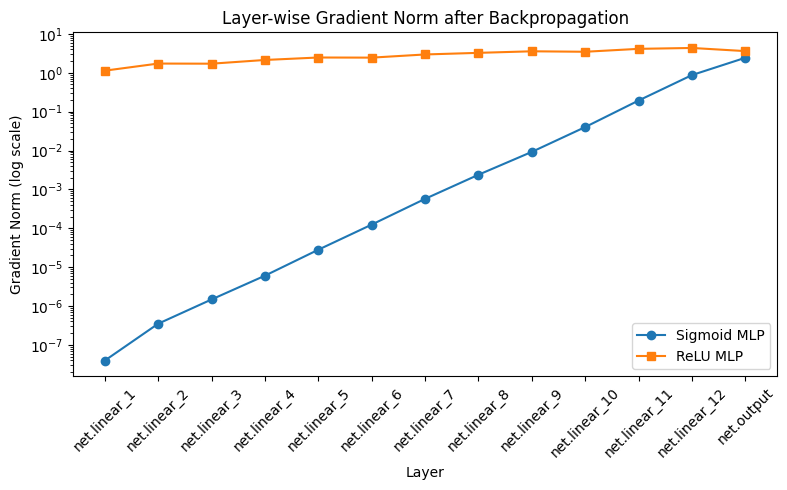

In [15]:
names, grads_sig, grads_relu = run_single_backward_demo()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(grads_sig)+1), grads_sig, marker='o', label='Sigmoid MLP')
plt.plot(range(1, len(grads_relu)+1), grads_relu, marker='s', label='ReLU MLP')
plt.yscale('log')
plt.xticks(range(1, len(grads_sig)+1), names, rotation=45)
plt.xlabel("Layer")
plt.ylabel("Gradient Norm (log scale)")
plt.title("Layer-wise Gradient Norm after Backpropagation")
plt.legend()
plt.tight_layout()
plt.show()

## MNIST 데이터셋 학습하기

MLP로 MNIST 데이터셋 직접 학습해보기

**Step 1. MNIST 데이터 로드 & 전처리**

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 재현성
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# 데이터 전처리: 28x28 이미지를 784차원 벡터로 펼침
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# MNIST 데이터 다운로드
train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print(f"Input shape: {train_dataset[0][0].shape}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 503kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.12MB/s]

Train: 60000, Test: 10000
Input shape: torch.Size([1, 28, 28])


**Step 2. MLP 모델 클래스 정의**

In [18]:
class MnistMLP(nn.Module):
  def __init__(self, hidden_dim=256, num_hidden=3):
    super().__init__()
    layers = []
    # 입력층: 28*28=784 -> hidden_dim
    layers.append(nn.Linear(784, hidden_dim))
    layers.append(nn.ReLU())

    # 은닉층 반복
    for _ in range(num_hidden - 1):
      layers.append(nn.Linear(hidden_dim, hidden_dim))
      layers.append(nn.ReLU())

    # 출력층: 10개 클래스 (0~9 숫자
    layers.append(nn.Linear(hidden_dim, 10))
    self.net = nn.Sequential(*layers)

  def forward(self, x):
    x = x.view(x.size(0), -1) # 이미지를 벡터로 펼침 (-1은 알아서 계산하라는 의미)
    return self.net(x)

**Step 2-2. 학습 & 평가 함수 정의**

In [19]:
from tqdm import tqdm
# 학습 함수 (1 epoch)
def train_epoch(model, loader, criterion, optimizer):
  model.train()
  total_loss, correct, total = 0, 0, 0
  pbar = tqdm(loader) # 모델 학습 진행 시각화

  for x, y in pbar:
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    out = model(x)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * x.size(0)
    correct += (out.argmax(1) == y).sum().item()
    total += x.size(0)
  return total_loss / total, correct / total

# 평가 함수
def evaluate(model, loader, criterion):
  model.eval()
  total_loss, correct, total = 0, 0, 0
  with torch.no_grad():
    for x, y in loader:
      x, y = x.to(device), y.to(device)
      out = model(x)
      loss = criterion(out, y)
      total_loss += loss.item() * x.size(0)
      correct += (out.argmax(1) == y).sum().item()
      total += x.size(0)
  return total_loss / total, correct / total

**Step 3. 학습실행 & 학습 결과 시각화**

100%|██████████| 469/469 [00:13<00:00, 33.95it/s]


Epoch  1 | Train Loss: 0.2656 | Train Acc: 0.9188 | Test Acc: 0.9621


100%|██████████| 469/469 [00:16<00:00, 27.77it/s]


Epoch  2 | Train Loss: 0.1014 | Train Acc: 0.9684 | Test Acc: 0.9726


100%|██████████| 469/469 [00:16<00:00, 27.74it/s]


Epoch  3 | Train Loss: 0.0703 | Train Acc: 0.9780 | Test Acc: 0.9768


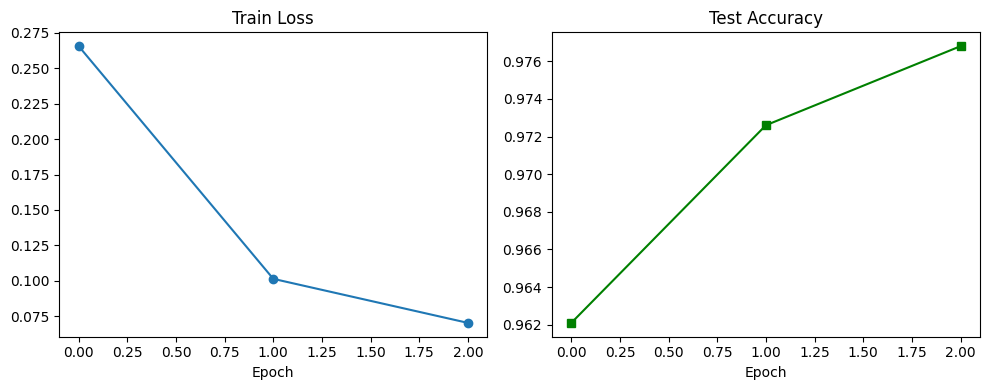

In [20]:
# 모델, 손실함수, 옵티마이저
model = MnistMLP(hidden_dim=256, num_hidden=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3) #Adam 대신 SGD 써도 됨

# 학습 루프
num_epochs = 3
train_losses, test_accs = [], []

for epoch in range(1, num_epochs + 1):
  train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
  test_loss, test_acc = evaluate(model, test_loader, criterion)
  train_losses.append(train_loss)
  test_accs.append(test_acc)
  print(f"Epoch {epoch:2d} | "
  f"Train Loss: {train_loss:.4f} | "
  f"Train Acc: {train_acc:.4f} | "
  f"Test Acc: {test_acc:.4f}")

# 결과 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(train_losses, marker='o')
ax1.set_title('Train Loss'); ax1.set_xlabel('Epoch')
ax2.plot(test_accs, marker='s', color='green')
ax2.set_title('Test Accuracy'); ax2.set_xlabel('Epoch')
plt.tight_layout(); plt.show()

**Step 4. 예측 결과 시각화**

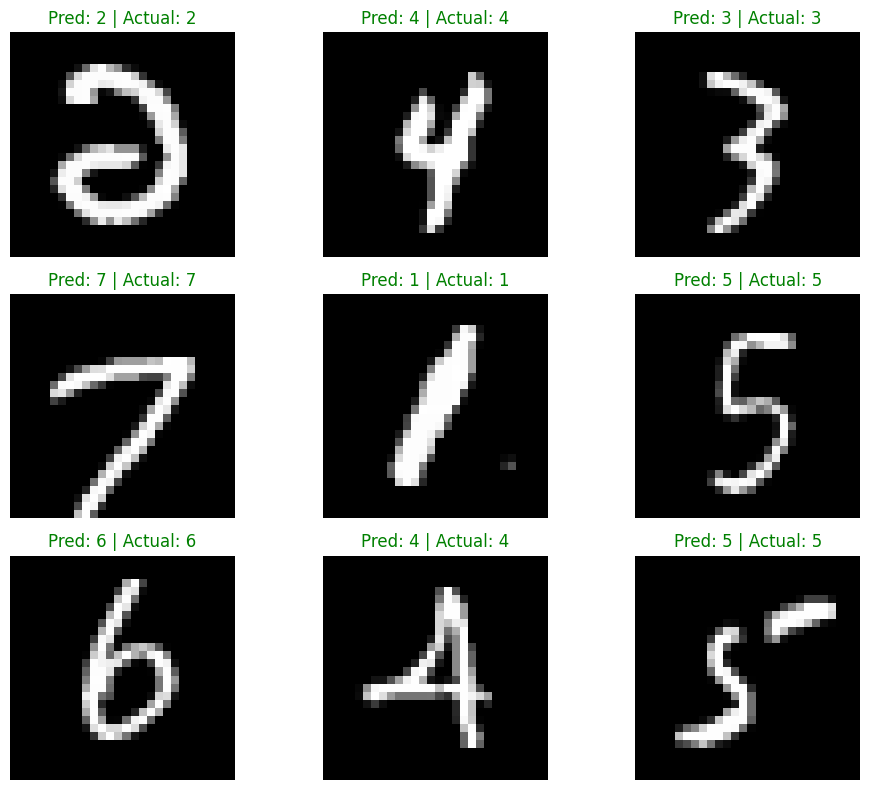

In [21]:
model.eval()
fig = plt.figure(figsize=(10, 8))
for i in range(1, 10):
  img_idx = torch.randint(0, len(test_dataset), (1,)).item()
  img, label = test_dataset[img_idx]

  with torch.no_grad():
    output = model(img.unsqueeze(0).to(device)) # img[1, 28, 28] > img [1, 1, 28, 28] | N차원에 1의 값을 넣어줌
    # img.squeeze(N) > N번째 차원을 없애줌
    # 여기서 사용한 이유: DataLoader에서 img.shape[128, 1, 28, 28]로 들어왔기 때문

  prediction = output.argmax(1).item()

  ax = fig.add_subplot(3, 3, i)
  ax.imshow(img.squeeze().cpu().numpy(), cmap='gray')
  ax.set_title(f"Pred: {prediction} | Actual: {label}", color='green' if prediction == label else 'red')
  ax.axis('off')
plt.tight_layout()
plt.show()